IMDB Sentiment Analysis with RNN

In [3]:
!conda create -n dl_rnn_env python=3.10 -y
!conda activate dl_rnn_env
!pip install numpy==1.26.4 tensorflow keras pandas scikit-learn matplotlib seaborn nltk

Retrieving notices: ...working... done
Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\Herath kumara\anaconda3\envs\dl_rnn_env

  added / updated specs:
    - python=3.10


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.9.9   |       haa95532_0         127 KB
    expat-2.7.1                |       h8ddb27b_0         259 KB
    libzlib-1.3.1              |       h02ab6af_0          64 KB
    openssl-3.0.18             |       h543e019_0         6.8 MB
    pip-25.2                   |     pyhc872135_0         1.2 MB
    python-3.10.18             |       h981015d_0        16.2 MB
    setuptools-78.1.1          |  py310haa95532_0         1.7 MB
    sqlite-3.50.2              |       hda9a48d_1        1017 KB
    tk-8.6.15                  |       hf199647_0         3.5 MB
    tzdata-20

'C:\Users\Herath kumara\anaconda3\envs\dl_rnn_env'
Spaces in paths can sometimes be problematic. To minimize issues,
make sure you activate your environment before running any executables!



   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   -- ------------------------------------- 1.0/15.5 MB 7.1 MB/s eta 0:00:03
   -------- ------------------------------- 3.4/15.5 MB 10.6 MB/s eta 0:00:02
   ------------ --------------------------- 5.0/15.5 MB 11.2 MB/s eta 0:00:01
   -------------------- ------------------- 8.1/15.5 MB 10.9 MB/s eta 0:00:01
   ---------------------- ----------------- 8.9/15.5 MB 11.1 MB/s eta 0:00:01
   ---------------------- ----------------- 8.9/15.5 MB 11.1 MB/s eta 0:00:01
   ---------------------- ----------------- 8.9/15.5 MB 11.1 MB/s eta 0:00:01
   ------------------------ --------------- 9.4/15.5 MB 6.1 MB/s eta 0:00:02
   ------------------------- -------------- 9.7/15.5 MB 5.5 MB/s eta 0:00:02
   ------------------------- -------------- 10.0/15.5 MB 5.2 MB/s eta 0:00:02
   -------------------------- ------------- 10.2/15.5 MB 4.7 MB/s eta 0:00:02
   --------------------------- ------------ 10.5/15.5 MB 4.4 MB/s eta 0:00:

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 11.3.0 which is incompatible.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [3]:

# =====================
# 1. Load Dataset
# =====================
df = pd.read_csv("IMDB Dataset.csv")

print(df.head())
print(df['sentiment'].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [4]:
# =====================
# 2. Preprocessing
# =====================
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)   # remove HTML tags
    text = re.sub(r"[^a-zA-Z']", " ", text)   # keep only words
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

df['cleaned'] = df['review'].apply(clean_text)

# Encode target
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

[nltk_data] Downloading package stopwords to C:\Users\Herath
[nltk_data]     kumara\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [5]:
# =====================
# 3. Tokenization
# =====================
max_words = 10000  # vocabulary size
max_len = 200      # sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned'])
sequences = tokenizer.texts_to_sequences(df['cleaned'])
X = pad_sequences(sequences, maxlen=max_len)

y = df['label'].values

# Train-Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)


Training samples: (40000, 200)
Test samples: (10000, 200)


In [6]:
# =====================
# 4. Build RNN Models
# =====================

def build_rnn_model(units=64, layers=1, dropout_rate=0.3, activation="tanh"):
    model = Sequential()
    model.add(Embedding(max_words, 128, input_length=max_len))
    
    # Add RNN layers
    for i in range(layers):
        return_sequences = (i < layers-1)
        model.add(SimpleRNN(units, activation=activation, return_sequences=return_sequences))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation="sigmoid"))
    
    model.compile(loss="binary_crossentropy", 
                  optimizer=Adam(learning_rate=1e-3), 
                  metrics=["accuracy"])
    return model

In [7]:
# =====================
# 5. Train and Compare
# =====================

# Variant 1: Simple Vanilla RNN
rnn1 = build_rnn_model(units=64, layers=1, dropout_rate=0.3)
history1 = rnn1.fit(X_train, y_train, epochs=5, batch_size=128, 
                    validation_split=0.2, verbose=1)

# Variant 2: Stacked RNN (2 layers)
rnn2 = build_rnn_model(units=64, layers=2, dropout_rate=0.4)
history2 = rnn2.fit(X_train, y_train, epochs=5, batch_size=128, 
                    validation_split=0.2, verbose=1)

# Variant 3: RNN with ReLU activation
rnn3 = build_rnn_model(units=64, layers=1, activation="relu")
history3 = rnn3.fit(X_train, y_train, epochs=5, batch_size=128, 
                    validation_split=0.2, verbose=1)

C:\Users\Herath kumara\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.7584 - loss: 0.4782 - val_accuracy: 0.8456 - val_loss: 0.3627
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.8971 - loss: 0.2629 - val_accuracy: 0.8706 - val_loss: 0.3321
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.9545 - loss: 0.1280 - val_accuracy: 0.8612 - val_loss: 0.4156
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.9846 - loss: 0.0479 - val_accuracy: 0.8309 - val_loss: 0.5568
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.9905 - loss: 0.0300 - val_accuracy: 0.8520 - val_loss: 0.5979
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 131ms/step - accuracy: 0.6876 - loss: 0.5647 - val_accuracy: 0.8385 - val_loss: 0.3828
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 118ms/step - accuracy: 0.8695 - loss: 0.3301 - val_accuracy: 0.8627 - val_loss: 0.3682
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9136 - loss: 0.2251 - val_a

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

Vanilla RNN Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.85      4961
           1       0.84      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



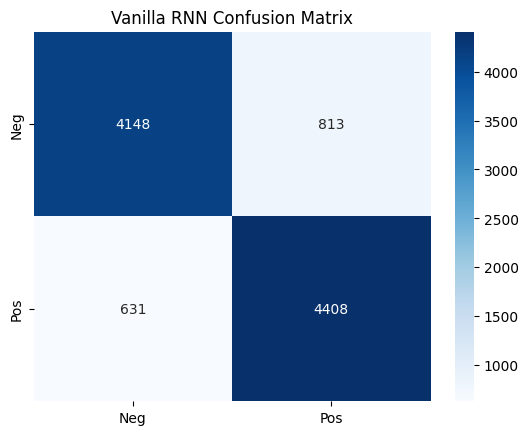

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step

Stacked RNN Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.83      4961
           1       0.83      0.85      0.84      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



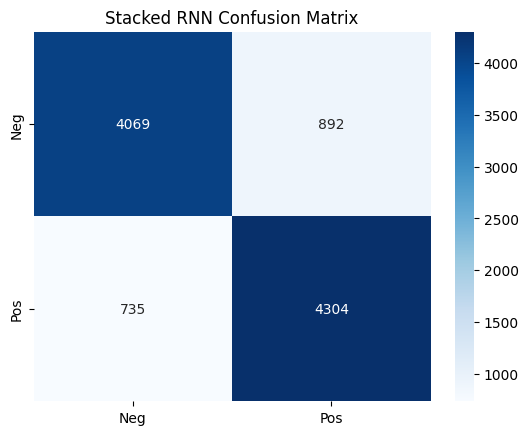

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

RNN ReLU Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86      4961
           1       0.85      0.88      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



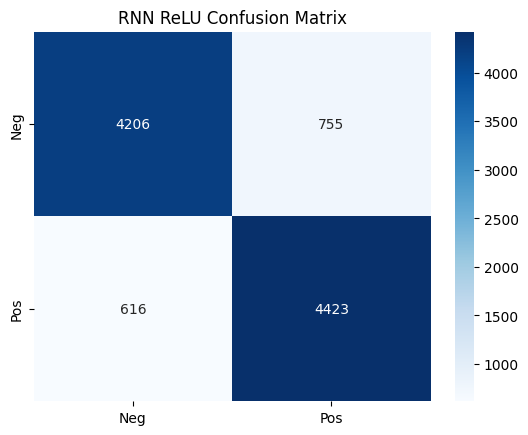

In [8]:
# =====================
# 6. Evaluation
# =====================

def evaluate_model(model, X_test, y_test, name="RNN"):
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    print(f"\n{name} Classification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"])
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return classification_report(y_test, y_pred, output_dict=True)

# Evaluate each
res1 = evaluate_model(rnn1, X_test, y_test, "Vanilla RNN")
res2 = evaluate_model(rnn2, X_test, y_test, "Stacked RNN")
res3 = evaluate_model(rnn3, X_test, y_test, "RNN ReLU")

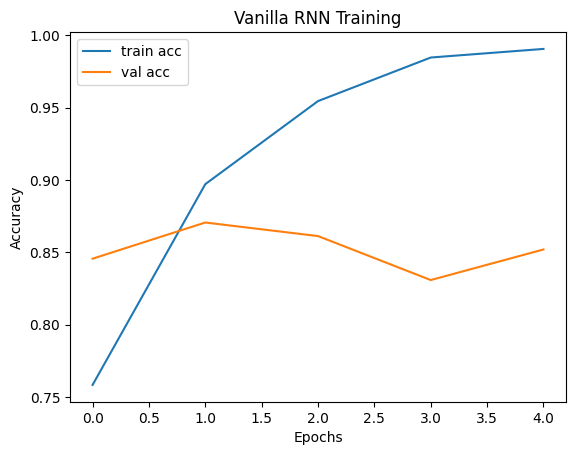

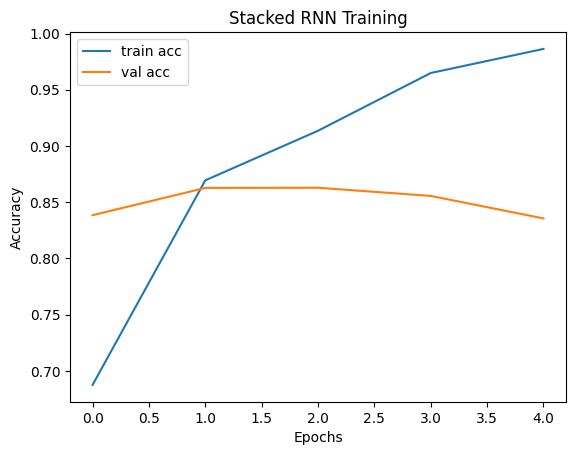

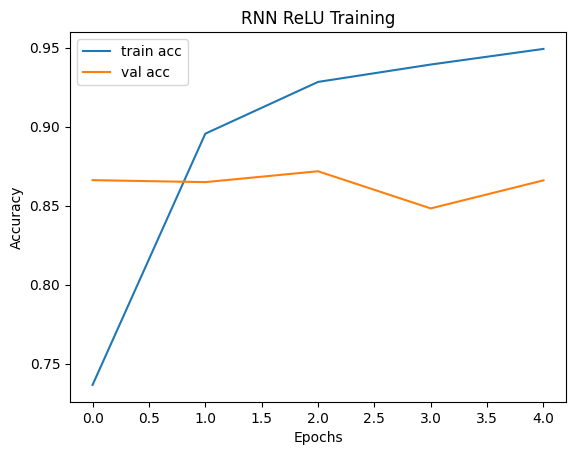

In [9]:
# =====================
# 7. Plot Training Curves
# =====================

def plot_history(history, title):
    plt.plot(history.history["accuracy"], label="train acc")
    plt.plot(history.history["val_accuracy"], label="val acc")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history1, "Vanilla RNN Training")
plot_history(history2, "Stacked RNN Training")
plot_history(history3, "RNN ReLU Training")